# 1D Evaporator Model

## -- Run Single Simulation --

In [ ]:
import sys
import os
from tqdm import tqdm
import copy
import CoolProp.CoolProp as CP

project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

from frost_evaporator.datamodels_nba import (
    FrostEvaporatorParameters, 
    FrostEvaporatorInputs, 
    FrostEvaporatorState,
    AirInputs,
    RefrigerantInputs,
)

from frost_evaporator_nba.frost_evaporator.frost_model import FrostModel
from frost_evaporator.air import AirModel
from frost_evaporator_nba.frost_evaporator.refrigerant_model import RefrigerantModel, propane_RP
from frost_evaporator_nba.frost_evaporator.hmt_model import HeatMassTransferModel
from frost_evaporator_nba.frost_evaporator.thermo_model import ThermoModel



#############################################################################
# Define Parameters
#############################################################################

AIR_LAYERS = 2

params = FrostEvaporatorParameters(
    # General
    time_step=120.0,  # [s]
    gravity=9.81,  # [m/s^2]

    # Correlations Choices
    frost_density_correlation_choice="da_silva_paper",
    frost_thickness_correlation_choice="jonas_diss",
    frost_conductivity_correlation_choice="da_silva_paper",
    nusselt_correlation_choice="N2",

    # Fan and Air Side Pressure Loss Parameters
    correction_factor_h_conv_air=0.65,
    correction_factor_surface_density=0.8,
    correction_factor_eta_fin=0.7,
    correction_factor_k_frost=1.0,
    correction_factor_pressure_loss=1.2,

    correction_factor_betta_air=1.0,

    # Geometrie Parameters
    fin_pitch=0.0025,  # [m] Calculated: 4 fins/cm = 0.25 cm pitch = 2.5 mm
    fin_height=0.152,  # [m] Paper: Height = 152 mm
    fin_length=0.045 / AIR_LAYERS,  # [m] Paper: Depth (air flow length) = 45 mm
    fin_thickness=0.0002,  # [m] Paper: 0.2 mm thickness
    fin_amount=128,  # [-] Calculated: Width (320mm) / Pitch (2.5mm) = 128 fins
    fin_thermal_conductivity=200.0,  # [W/mK] Paper: "Aluminum alloy" (Standard value usually ~200-220)
    tube_outer_diameter=0.010,  # [m] Paper: 10 mm Outer Diameter
    tube_inner_diameter=0.008,  # [m] Paper: 1 mm wall thickness -> ID = 10 - 2*1 = 8 mm
    tube_layers=2 / AIR_LAYERS,  # [-] Paper: "Two rows"
    tubes_per_layer=6,  # [-] Paper: "Six tubes per row"
    tube_thermal_conductivity=400, # [W/mK] Paper: Copper tubes (Standard value ~385-400)

    alpha_0=4300.0,  # [W/m^2K] - 4300 for propane, used for two phase htc (VDI H2 Tab. 1)
)

#############################################################################
# Define Inputs
#############################################################################

# Useless, because Paper uses constant surface temp
refrigerant_inputs = RefrigerantInputs(
    h_in = 0.0,  # [J/kg]
    p_eva = 0.0,  # [Pa]
    m_dot= 0.0,  # [kg/s]
)

# Define the inputs for the air
T_air_in_val = 273.15 + 2.5
p_air_in_val = 101325.0
R_air_in_val = 0.85  # Input Relative Humidity [0-1]

# Calculate W_in from R_in
W_air_in_calculated = CP.HAPropsSI('W', 'T', T_air_in_val, 'P', p_air_in_val, 'R', R_air_in_val)

global_air_inputs = AirInputs(
    T_in = T_air_in_val,
    p_in = p_air_in_val,
    W_in = W_air_in_calculated 
)

global_inputs = FrostEvaporatorInputs(
    air_inputs   = global_air_inputs,
    refrigerant_inputs = refrigerant_inputs
)


#############################################################################
# Create Models
#############################################################################
frost_model = FrostModel(params)
air_model   = AirModel(params)
refrigerant_model = RefrigerantModel(params, propane_RP)
hmt_model = HeatMassTransferModel(params)
thermo_model = ThermoModel(params)


#############################################################################
# Initialization: 1D Discretization
#############################################################################
states = []

# Initialize a state for each layer
for i in range(AIR_LAYERS):
    s = FrostEvaporatorState()
    # Initialize guesses
    s.hmt.set("T_frost_surface", 268)
    s.hmt.set("T_frost_base", 268)
    s.air.set("T_out", global_air_inputs.T_in) # Initial guess
    s.air.set("reynolds", 2000)
    s.air.set("T_dew_point", 260)
    s.frost.set("density", 100)
    s.frost.set("mass", 1e-9)
    s.refrigerant.set("h_out", global_inputs.refrigerant.h_in + 100.0)
    
    # Constant wall temp assumption for now
    T_surface_temporary = 273.15 - 10
    s.refrigerant.set("T_in", T_surface_temporary)
    s.refrigerant.set("T_out", T_surface_temporary)

    # Initial Step Forward to populate derived values
    frost_model.step_forward(s, global_inputs)
    
    states.append(s)


#############################################################################
# Simulation Loop
#############################################################################

states_history = []
velocity_history = []
total_iterations = 0

simulation_steps = int(76 * (60 / params.time_step))

for j in tqdm(range(simulation_steps)):
    converged = False 
    
    # Inner loop to converge Thermodynamics & Air Flow
    for i in range(200):
        
        # Solve Global Air Flow (Fan-System Interaction)
        # This updates 'velocity' and 'm_dot' in ALL states based on current resistances.
        air_model.solve_fan_system_equilibrium(states, global_inputs)


        # Iterate through layers (Output of Layer i -> Input of Layer i+1)
        current_air_input = copy.deepcopy(global_inputs.air) # Start with global air

        # Track max residual for convergence
        max_residual = 0.0
        for k in range(AIR_LAYERS):
            state = states[k]
            # Get previous check value
            T_prev = state.hmt.T_frost_surface
            
            # Prepare Inputs for this layer
            layer_inputs = FrostEvaporatorInputs(
                air_inputs=current_air_input,
                refrigerant_inputs=global_inputs.refrigerant
            )

            # Update Models for this layer
            frost_model.update_properties(state, layer_inputs)
            air_model.update_properties(state, layer_inputs)
            hmt_model.update_properties(state, layer_inputs)
            thermo_model.update_properties(state, layer_inputs)

            # Prepare inputs for NEXT layer (k+1)           
            current_air_input = AirInputs(
                T_in = state.air.T_out,
                p_in = state.air.p_out,
                W_in = state.air.W_out
            )
            
            # Convergence Check Accumulation
            T_new = state.hmt.T_frost_surface
            max_residual = max(max_residual, abs(T_new - T_prev))

        # Check Global Convergence
        if max_residual < 1e-3:
            converged = True
            total_iterations += i+1
            break

    if not converged:
        print(f"\nCRASH at timestep {j}. Residual: {max_residual}")
        break 
        
    # Check Choke
    if states[0].air.m_dot_humid < 1e-3:
        print(f"\nAir Choke at timestep {j}")
        break

    # Save History
    states_history.append([s.copy() for s in states]) 
    
    # Step Forward (Physical time step)
    # We must pass the correct inputs to step_forward too!
    current_air_input_step = copy.deepcopy(global_inputs.air)
    for k in range(AIR_LAYERS):
        state = states[k]
        layer_inputs = FrostEvaporatorInputs(
            air_inputs=current_air_input_step,
            refrigerant_inputs=global_inputs.refrigerant
        )
        frost_model.step_forward(state, layer_inputs)
        
        # Prepare inputs for next layer step
        next_T_in = state.air.T_out
        next_W_in = state.air.W_out
        current_air_input_step = AirInputs(T_in=next_T_in, p_in=global_air_inputs.p_in, W_in=next_W_in)

# ... (Printing results) ...
print(f"Final Outlet Temp: {states[-1].air.T_out}")
print(f"Inlet Frost Thickness: {states[0].frost.thickness}")
print(f"Outlet Frost Thickness: {states[-1].frost.thickness}")
print(f"Average Iterations per Timestep: {(total_iterations/simulation_steps)} \n" )
print(params.__str__())
print("\n\n\n\n")
print(global_inputs.__str__())
print("\n\n\n\n")
print(state.__str__())

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd

# ---------------------------------------------------------
# 1. PREPARE DATA
# ---------------------------------------------------------
n_steps = len(states_history)
num_layers = len(states_history[0]) # Detect number of layers
dt = params.time_step 
time_axis = [i * dt / 60 for i in range(n_steps)]

# Initialize storage for aggregated data (1 value per timestep)
data_agg = {
    'Time': time_axis,
    'Q_dot_total': [],
    'Q_dot_sens': [],
    'p_delta_total': [],
    'mass_frost_total': [],
    'm_dot_air_global': [], # Mass flow is constant across layers (continuity)
    'vol_flow_fan': [],     # Volume flow at fan inlet (Layer 0)
}

# Initialize storage for per-layer data (N values per timestep)
# We will use a dictionary of lists of lists to build columns later
layer_vars = [
    'T_air_out', 'T_frost_surf', 'W_out', 'W_frost_sat', 'R_out', 
    'thickness', 'density', 'space', 
    'm_dot_densification', 'm_dot_thickening',
    'h_conv', 'eta_fin', 'velocity', 'Re', 'p_drop'
]
data_layers = {var: [[] for _ in range(num_layers)] for var in layer_vars}

# --- Loop through History ---
for step_states in states_history:
    
    # 1. Global / Summed Values
    # Sum heat transfer across all layers
    q_tot = sum(s.hmt.Q_dot_total for s in step_states)
    q_sens = sum(s.hmt.Q_dot_sens for s in step_states)
    
    # Sum frost mass
    m_frost = sum(s.frost.mass for s in step_states)
    
    # Total Pressure Drop = Inlet Pressure of Layer 0 - Ambient
    # (Assuming Layer 0 is the entrance)
    dp_tot = global_inputs.air.p_in - step_states[-1].air.p_out # params.ambient_pressure
    
    # Flow (Continuity -> Mass flow same, use Layer 0)
    m_dot_air = step_states[0].air.m_dot_humid
    v_dot_air = 3600 * m_dot_air / step_states[0].air.density_avg
    
    data_agg['Q_dot_total'].append(q_tot)
    data_agg['Q_dot_sens'].append(q_sens)
    data_agg['mass_frost_total'].append(m_frost)
    data_agg['p_delta_total'].append(dp_tot)
    data_agg['m_dot_air_global'].append(m_dot_air)
    data_agg['vol_flow_fan'].append(v_dot_air)

    # 2. Per-Layer Values
    for i, s in enumerate(step_states):
        data_layers['T_air_out'][i].append(s.air.T_out)
        data_layers['T_frost_surf'][i].append(s.hmt.T_frost_surface)
        data_layers['W_out'][i].append(s.air.W_out)
        data_layers['W_frost_sat'][i].append(s.air.W_frost_surface_sat)
        data_layers['R_out'][i].append(s.air.R_out)
        
        data_layers['thickness'][i].append(s.frost.thickness)
        data_layers['density'][i].append(s.frost.density)
        data_layers['space'][i].append(s.frost.space_between_frost)
        
        data_layers['m_dot_densification'][i].append(s.hmt.m_dot_densification)
        data_layers['m_dot_thickening'][i].append(s.hmt.m_dot_thickening)
        
        data_layers['h_conv'][i].append(s.air.h_conv)
        data_layers['eta_fin'][i].append(s.hmt.eta_fin)
        data_layers['velocity'][i].append(s.air.velocity)
        data_layers['Re'][i].append(s.air.reynolds)
        data_layers['p_drop'][i].append(s.air.pressure_drop)

# --- Create DataFrame ---
df = pd.DataFrame(data_agg)
df.set_index('Time', inplace=True)

# Add per-layer columns (e.g., 'thickness_L0', 'thickness_L1')
for var in layer_vars:
    for i in range(num_layers):
        col_name = f"{var}_L{i}"
        df[col_name] = data_layers[var][i]

# Add Constant Inputs for Reference
df['T_air_in'] = global_inputs.air.T_in
df['W_in'] = global_inputs.air.W_in # Input to Layer 0

# ---------------------------------------------------------
# 2. PLOT CONFIGURATION
# ---------------------------------------------------------

# Helper to generate list of column names for all layers
def get_layer_cols(base_name):
    return [f"{base_name}_L{i}" for i in range(num_layers)]

plots_config = [
    # --- ROW 1: Thermals ---
    (1, 1, ['T_air_in'] + get_layer_cols('T_air_out') + get_layer_cols('T_frost_surf'), "Temperatures [K]"), 
    (1, 2, ['Q_dot_total', 'Q_dot_sens'], "Total Heat Transfer (Sum) [W]"),
    (1, 3, ['W_in'] + get_layer_cols('W_out'), "Humidity Ratio [kg/kg]"),
    (1, 4, get_layer_cols('eta_fin'), "Fin Efficiency [-]"),
    (1, 5, get_layer_cols('R_out'), "Rel. Humidity Out [-]"),
    
    # --- ROW 2: Air Flow ---
    (2, 1, ['p_delta_total'] + get_layer_cols('p_drop'), "Pressure Drop [Pa]"),
    (2, 2, ['vol_flow_fan'], "Fan Volume Flow [m³/h]"),
    (2, 3, get_layer_cols('velocity'), "Local Velocity [m/s]"),
    (2, 4, ['m_dot_air_global'], "Mass Flow [kg/s]"),
    (2, 5, get_layer_cols('h_conv'), "Local h_conv [W/m²K]"),
    
    # --- ROW 3: Frost ---
    (3, 1, ['mass_frost_total'], "Total Frost Mass [kg]"),
    (3, 2, get_layer_cols('m_dot_thickening'), "Thickening Rate [kg/s]"),
    (3, 3, get_layer_cols('thickness'), "Frost Thickness [m]"),
    (3, 4, get_layer_cols('density'), "Frost Density [kg/m³]"),
    (3, 5, get_layer_cols('space'), "Air Gap [m]"),
]

fig = make_subplots(
    rows=3, cols=5, 
    subplot_titles=[p[3] for p in plots_config],
    vertical_spacing=0.1, horizontal_spacing=0.04
)

# Color scale for layers to distinguish them easily
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] # Blue, Orange, Green, Red

for row, col, cols_to_plot, title in plots_config:
    for col_name in cols_to_plot:
        
        # Style Logic
        line_style = dict()
        
        # Color logic: assign specific colors to specific layers if detected
        trace_color = None
        if "_L" in col_name:
            try:
                layer_idx = int(col_name.split("_L")[-1])
                trace_color = colors[layer_idx % len(colors)]
            except:
                pass
        
        # Special styling for Inputs
        if "_in" in col_name and "L" not in col_name:
             line_style = dict(dash='dot', color='black')
             trace_color = None # Override
        
        fig.add_trace(
            go.Scatter(
                x=df.index, y=df[col_name], name=col_name,
                line=line_style,
                marker=dict(color=trace_color) if trace_color else None,
                legendgroup=title, # Group items by plot for cleaner toggling (optional)
            ),
            row=row, col=col
        )

# ---------------------------------------------------------
# 3. LAYOUT & INTERACTIVITY
# ---------------------------------------------------------
fig.update_layout(
    height=900, width=1600, 
    hovermode="x unified",
    showlegend=False,
    title_text=f"1D Frost Simulation Results ({num_layers} Layers)",
    margin=dict(l=20, r=20, t=60, b=20)
)

fig.update_xaxes(matches='x')
fig.update_xaxes(title_text="Time [min]", row=3)

# Add a note about colors
print(f"Plotting complete. Layer 0 (Inlet) is Blue, Layer {num_layers-1} (Outlet) is Orange/Green.")

fig.show()

##  Optimization

In [ ]:
import sys
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from tqdm import tqdm
import copy
import CoolProp.CoolProp as CP

project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

from frost_evaporator.datamodels_nba import (
    FrostEvaporatorParameters, 
    FrostEvaporatorInputs, 
    FrostEvaporatorState,
    AirInputs,
    RefrigerantInputs,
)

from frost_evaporator_nba.frost_evaporator.frost_model import FrostModel
from frost_evaporator.air import AirModel
from frost_evaporator_nba.frost_evaporator.refrigerant_model import RefrigerantModel, propane_RP
from frost_evaporator_nba.frost_evaporator.hmt_model import HeatMassTransferModel
from frost_evaporator_nba.frost_evaporator.thermo_model import ThermoModel



#############################################################################
# Define Parameters
#############################################################################

AIR_LAYERS = 2

params = FrostEvaporatorParameters(
    # General
    time_step=20.0,  # [s]
    gravity=9.81,  # [m/s^2]

    # Correlations Choices
    frost_density_correlation_choice="da_silva_paper",
    frost_thickness_correlation_choice="jonas_diss",
    frost_conductivity_correlation_choice="da_silva_paper",
    nusselt_correlation_choice="N2",

    # Fan and Air Side Pressure Loss Parameters
    correction_factor_h_conv_air=0.65,
    correction_factor_surface_density=0.8,
    correction_factor_eta_fin=0.7,
    correction_factor_k_frost=1.0,
    correction_factor_pressure_loss=1.2,

    correction_factor_betta_air=1.0,

    # Geometrie Parameters
    fin_pitch=0.0025,  # [m] Calculated: 4 fins/cm = 0.25 cm pitch = 2.5 mm
    fin_height=0.152,  # [m] Paper: Height = 152 mm
    fin_length=0.045 / AIR_LAYERS,  # [m] Paper: Depth (air flow length) = 45 mm
    fin_thickness=0.0002,  # [m] Paper: 0.2 mm thickness
    fin_amount=128,  # [-] Calculated: Width (320mm) / Pitch (2.5mm) = 128 fins
    fin_thermal_conductivity=200.0,  # [W/mK] Paper: "Aluminum alloy" (Standard value usually ~200-220)
    tube_outer_diameter=0.010,  # [m] Paper: 10 mm Outer Diameter
    tube_inner_diameter=0.008,  # [m] Paper: 1 mm wall thickness -> ID = 10 - 2*1 = 8 mm
    tube_layers=2 / AIR_LAYERS,  # [-] Paper: "Two rows"
    tubes_per_layer=6,  # [-] Paper: "Six tubes per row"
    tube_thermal_conductivity=400, # [W/mK] Paper: Copper tubes (Standard value ~385-400)

    alpha_0=4300.0,  # [W/m^2K] - 4300 for propane, used for two phase htc (VDI H2 Tab. 1)
)


#############################################################################
# 2. Define the Simulation Function
#############################################################################
def run_simulation_case(case_name, T_air_C, RH_in, T_surf_C, duration_mins, color):
    """
    Runs the multi-layer simulation for a specific set of boundary conditions.
    Returns a DataFrame of aggregated results and the assigned color.
    """
    print(f"--- Starting Simulation: {case_name} ---")
    print(f"Inputs: T_air={T_air_C}°C, RH={RH_in*100}%, T_surf={T_surf_C}°C, Time={duration_mins}min")

    # --- Setup Inputs ---
    refrigerant_inputs = RefrigerantInputs(h_in=0.0, p_eva=0.0, m_dot=0.0)

    T_air_in_val = 273.15 + T_air_C
    p_air_in_val = 101325.0
    R_air_in_val = RH_in

    # Calculate W_in
    W_air_in_calculated = CP.HAPropsSI('W', 'T', T_air_in_val, 'P', p_air_in_val, 'R', R_air_in_val)

    global_air_inputs = AirInputs(
        T_in = T_air_in_val,
        p_in = p_air_in_val,
        W_in = W_air_in_calculated 
    )

    global_inputs = FrostEvaporatorInputs(
        air_inputs=global_air_inputs,
        refrigerant_inputs=refrigerant_inputs
    )

    # --- Instantiate Models (Fresh for each run) ---
    frost_model = FrostModel(params)
    air_model   = AirModel(params)
    hmt_model   = HeatMassTransferModel(params)
    thermo_model = ThermoModel(params)
    # refrigerant_model not strictly needed for constant T_surf, but initialized if needed
    
    # --- Initialization: 1D Discretization ---
    states = []
    T_surface_kelvin = 273.15 + T_surf_C

    # Initialize a state for each layer
    for i in range(AIR_LAYERS):
        s = FrostEvaporatorState()
        s.hmt.set("T_frost_surface", 268)
        s.hmt.set("T_frost_base", 268)
        s.air.set("T_out", global_air_inputs.T_in)
        s.air.set("reynolds", 2000)
        s.air.set("T_dew_point", 260)
        s.frost.set("density", 100)
        s.frost.set("mass", 1e-9)
        s.refrigerant.set("h_out", 0.0) # Dummy
        
        # Force Surface Temperature
        s.refrigerant.set("T_in", T_surface_kelvin)
        s.refrigerant.set("T_out", T_surface_kelvin)

        # Initial Step Forward
        frost_model.step_forward(s, global_inputs)
        states.append(s)

    # --- Time Loop ---
    states_history = []
    simulation_steps = int(duration_mins * (60 / params.time_step))
    
    for j in tqdm(range(simulation_steps), desc=case_name):
        converged = False 
        
        # Inner loop to converge Thermodynamics & Air Flow
        for i in range(200):
            # 1. Solve Global Air Flow (Fan Equilibrium)
            air_model.solve_fan_system_equilibrium(states, global_inputs)

            # 2. Iterate through layers
            current_air_input = copy.deepcopy(global_inputs.air)
            max_residual = 0.0

            for k in range(AIR_LAYERS):
                state = states[k]
                T_prev = state.hmt.T_frost_surface
                
                # Layer Inputs
                layer_inputs = FrostEvaporatorInputs(
                    air_inputs=current_air_input,
                    refrigerant_inputs=global_inputs.refrigerant
                )

                # Update Models
                frost_model.update_properties(state, layer_inputs)
                air_model.update_properties(state, layer_inputs)
                hmt_model.update_properties(state, layer_inputs)
                thermo_model.update_properties(state, layer_inputs)

                # Prepare inputs for NEXT layer
                current_air_input = AirInputs(
                    T_in = state.air.T_out,
                    p_in = state.air.p_out, 
                    W_in = state.air.W_out
                )
                
                # Convergence Check
                T_new = state.hmt.T_frost_surface
                max_residual = max(max_residual, abs(T_new - T_prev))

            if max_residual < 1e-3:
                converged = True
                break
        
        if not converged:
            print(f"!!! CRASH in {case_name} at step {j} !!! Residual: {max_residual}")
            break 

        if states[0].air.m_dot_humid < 1e-3:
            print(f"!!! Air Choke in {case_name} at step {j} !!!")
            break 

        # Store History (Deepcopy list of states)
        states_history.append([s.copy() for s in states])
        
        # --- Physical Step Forward ---
        current_air_input_step = copy.deepcopy(global_inputs.air)
        for k in range(AIR_LAYERS):
            state = states[k]
            layer_inputs = FrostEvaporatorInputs(
                air_inputs=current_air_input_step,
                refrigerant_inputs=global_inputs.refrigerant
            )
            frost_model.step_forward(state, layer_inputs)
            
            # Prepare inputs for next layer step
            next_T_in = state.air.T_out
            next_W_in = state.air.W_out
            current_air_input_step = AirInputs(T_in=next_T_in, p_in=global_air_inputs.p_in, W_in=next_W_in)

    # --- Post-Process Data into DataFrame ---
    # We aggregate data from the layers (Sum Q, Avg Thickness, Last T_out, etc.)
    time_axis = [i * params.time_step / 60 for i in range(len(states_history))]

    # Helper to extract data from history
    def get_layer_sum(attr_path):
        """Sums an attribute across all layers for every timestep"""
        vals = []
        for step_states in states_history:
            total = 0.0
            for s in step_states:
                # Traverse path like s.hmt.Q_dot_total
                obj = s
                for attr in attr_path.split('.'):
                    obj = getattr(obj, attr)
                total += obj
            vals.append(total)
        return vals
    
    # Extract mass flow from first layer (conserved mostly)
    m_dot_history = [step[0].air.m_dot_humid for step in states_history]
    
    data = {      
        # Heat Transfer (Summed)
        'Q_dot_total': get_layer_sum("hmt.Q_dot_total"),
        'vol_flow': [3600 * m_dot / step[0].air.density_avg for m_dot, step in zip(m_dot_history, states_history)]
    }
    
    df = pd.DataFrame(data)
    df['Time'] = time_axis
    df.set_index('Time', inplace=True)
    
    return df, color

#############################################################################
# 3. Execution Block
#############################################################################



# ---------------------------------------------------------
# 2. LOAD & CLEAN EXPERIMENTAL DATA
# ---------------------------------------------------------
def load_and_clean_csv(filepath):
    """
    Loads CSV, forces numeric conversion, drops bad rows, and resets index.
    """
    # Load without header
    df = pd.read_csv(filepath, header=None)
    df.columns = ['Time', 'value']
    
    # Force numeric conversion (turns headers/strings into NaN)
    df['Time'] = pd.to_numeric(df['Time'], errors='coerce')
    df['value'] = pd.to_numeric(df['value'], errors='coerce')
    
    # Drop NaNs and reset index to standard RangeIndex (0, 1, 2...)
    df = df.dropna().reset_index(drop=True)
    
    return df

# Define paths
vol_flow_path = r"J:\Masterarbeit_Nils_Baumeister\da_Silva_Daten_extrahiert\air_flow_rate_case2_validation.csv"
q_dot_path = r"J:\Masterarbeit_Nils_Baumeister\da_Silva_Daten_extrahiert\cooling_capacity_case2_validation.csv"

# Load data
experiment_vol_flow = load_and_clean_csv(vol_flow_path)
experiment_Q_dot_total = load_and_clean_csv(q_dot_path)



# Define the 3 simulations from the paper
simulations_config = [
    ("Case 2 (2.5°C, 85%)", 2.5, 0.85, -10.0, 76,  "blue"),
]

results = {}

# Run them all
for sim_conf in simulations_config:
    name, t_in, rh, t_surf, dur, col = sim_conf
    try:
        my_data, color_res = run_simulation_case(name, t_in, rh, t_surf, dur, col)

        print("--- My Simulation Data ---")
        print(my_data.head())
        print("\n--- Exp: Volume Flow ---")
        print(experiment_vol_flow.head())
        print("\n--- Exp: Q_dot Total ---")
        print(experiment_Q_dot_total.head())


    except Exception as e:
        print(f"Error running {name}: {e}")
    

In [ ]:
import sys
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from tqdm import tqdm
import copy
import CoolProp.CoolProp as CP
import pickle

# --- Optimization Imports ---
from skopt import gp_minimize
from skopt.space import Real
from skopt.utils import use_named_args
from skopt.plots import plot_convergence

# Check project root setup
project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

# Import your specific modules (assuming these exist in your path as per your code)
from frost_evaporator.datamodels_nba import (
    FrostEvaporatorParameters, 
    FrostEvaporatorInputs, 
    FrostEvaporatorState,
    AirInputs,
    RefrigerantInputs,
)
from frost_evaporator_nba.frost_evaporator.frost_model import FrostModel
from frost_evaporator.air import AirModel
from frost_evaporator_nba.frost_evaporator.refrigerant_model import RefrigerantModel
from frost_evaporator_nba.frost_evaporator.hmt_model import HeatMassTransferModel
from frost_evaporator_nba.frost_evaporator.thermo_model import ThermoModel

# =============================================================================
# 1. SETUP & DATA LOADING
# =============================================================================

AIR_LAYERS = 2

# Load Validation Data
def load_and_clean_csv(filepath):
    df = pd.read_csv(filepath, header=None)
    df.columns = ['Time', 'value']
    df['Time'] = pd.to_numeric(df['Time'], errors='coerce')
    df['value'] = pd.to_numeric(df['value'], errors='coerce')
    return df.dropna().reset_index(drop=True)

# Update these paths to your actual paths
vol_flow_path = r"J:\Masterarbeit_Nils_Baumeister\da_Silva_Daten_extrahiert\air_flow_rate_case2_validation.csv"
q_dot_path = r"J:\Masterarbeit_Nils_Baumeister\da_Silva_Daten_extrahiert\cooling_capacity_case2_validation.csv"
frost_mass_path = r"J:\Masterarbeit_Nils_Baumeister\da_Silva_Daten_extrahiert\frost_mass_case2_validation.csv"

exp_vol_flow = load_and_clean_csv(vol_flow_path)
exp_Q_dot = load_and_clean_csv(q_dot_path)
exp_frost_mass = load_and_clean_csv(frost_mass_path)

# =============================================================================
# 2. CORE SIMULATION LOGIC (Refactored for dynamic parameters)
# =============================================================================

def run_simulation_dynamic(factors):
    """
    Runs the simulation with a specific set of correction factors.
    factors: dict containing the 5 correction factors
    """
    
    # Update Parameters with the factors provided by the optimizer
    params = FrostEvaporatorParameters(
        time_step=30.0,
        gravity=9.81,
        frost_density_correlation_choice="da_silva_paper",
        frost_thickness_correlation_choice="jonas_diss",
        frost_conductivity_correlation_choice="da_silva_paper",
        nusselt_correlation_choice="N2",
        
        # --- OPTIMIZED FACTORS ---
        correction_factor_h_conv_air=factors['h_conv'],
        correction_factor_surface_density=factors['surf_dens'],
        correction_factor_eta_fin=factors['eta_fin'],
        correction_factor_k_frost=factors['k_frost'],
        correction_factor_pressure_loss=factors['p_loss'],
        correction_factor_betta_air=factors['betta'],
        # -------------------------

        fin_pitch=0.0025,
        fin_height=0.152,
        fin_length=0.045 / AIR_LAYERS,
        fin_thickness=0.0002,
        fin_amount=128,
        fin_thermal_conductivity=200.0,
        tube_outer_diameter=0.010,
        tube_inner_diameter=0.008,
        tube_layers=2 / AIR_LAYERS,
        tubes_per_layer=6,
        tube_thermal_conductivity=400,
        alpha_0=4300.0,
    )

    # Simulation Config (Case 2 from your code)
    T_air_C = 2.5
    RH_in = 0.85
    T_surf_C = -10.0
    duration_mins = 76
    
    # --- Input Setup ---
    refrigerant_inputs = RefrigerantInputs(h_in=0.0, p_eva=0.0, m_dot=0.0)
    T_air_in_val = 273.15 + T_air_C
    p_air_in_val = 101325.0
    W_air_in_calculated = CP.HAPropsSI('W', 'T', T_air_in_val, 'P', p_air_in_val, 'R', RH_in)

    global_inputs = FrostEvaporatorInputs(
        air_inputs=AirInputs(T_in=T_air_in_val, p_in=p_air_in_val, W_in=W_air_in_calculated),
        refrigerant_inputs=refrigerant_inputs
    )

    # --- Model Instantiation ---
    frost_model = FrostModel(params)
    air_model = AirModel(params)
    hmt_model = HeatMassTransferModel(params)
    thermo_model = ThermoModel(params)

    # --- Initialization ---
    states = []
    T_surface_kelvin = 273.15 + T_surf_C
    for i in range(AIR_LAYERS):
        s = FrostEvaporatorState()
        s.hmt.set("T_frost_surface", 268); s.hmt.set("T_frost_base", 268)
        s.air.set("T_out", global_inputs.air.T_in); s.air.set("reynolds", 2000)
        s.air.set("T_dew_point", 260); s.frost.set("density", 100); s.frost.set("mass", 1e-9)
        s.refrigerant.set("h_out", 0.0); s.refrigerant.set("T_in", T_surface_kelvin); s.refrigerant.set("T_out", T_surface_kelvin)
        frost_model.step_forward(s, global_inputs)
        states.append(s)

    # --- Time Loop ---
    states_history = []
    simulation_steps = int(duration_mins * (60 / params.time_step))
    
    # Note: Removed tqdm here to keep optimization output clean
    for j in range(simulation_steps):
        converged = False
        for i in range(200):
            air_model.solve_fan_system_equilibrium(states, global_inputs)
            current_air_input = copy.deepcopy(global_inputs.air)
            max_residual = 0.0
            
            for k in range(AIR_LAYERS):
                state = states[k]
                T_prev = state.hmt.T_frost_surface
                layer_inputs = FrostEvaporatorInputs(air_inputs=current_air_input, refrigerant_inputs=global_inputs.refrigerant)
                
                frost_model.update_properties(state, layer_inputs)
                air_model.update_properties(state, layer_inputs)
                hmt_model.update_properties(state, layer_inputs)
                thermo_model.update_properties(state, layer_inputs)

                current_air_input = AirInputs(T_in=state.air.T_out, p_in=inputs.air.p_in, W_in=state.air.W_out)
                max_residual = max(max_residual, abs(state.hmt.T_frost_surface - T_prev))

            if max_residual < 1e-3:
                converged = True
                break
        
        if not converged: 
            return None # Signal failure
        if states[0].air.m_dot_humid < 1e-3: 
            return None # Signal failure

        states_history.append([s.copy() for s in states])
        
        # Step Forward
        current_air_input_step = copy.deepcopy(global_inputs.air)
        for k in range(AIR_LAYERS):
            state = states[k]
            layer_inputs = FrostEvaporatorInputs(air_inputs=current_air_input_step, refrigerant_inputs=global_inputs.refrigerant)
            frost_model.step_forward(state, layer_inputs)
            current_air_input_step = AirInputs(T_in=state.air.T_out, p_in=global_inputs.air.p_in, W_in=state.air.W_out)

    # --- Data Extraction ---
    time_axis = [i * params.time_step / 60 for i in range(len(states_history))]
    
    # Calculate Totals
    q_totals = []
    m_dots = []
    frost_mass = []
    for step_states in states_history:
        q_totals.append(sum(s.hmt.Q_dot_total for s in step_states))
        frost_mass.append(sum(s.frost.mass for s in step_states))

        m_dots.append(step_states[0].air.m_dot_humid)
        
        
    vol_flows = [3600 * m / step[0].air.density_avg for m, step in zip(m_dots, states_history)]

    df = pd.DataFrame({'Q_dot_total': q_totals, 'vol_flow': vol_flows, 'frost_mass': frost_mass})
    df['Time'] = time_axis
    df.set_index('Time', inplace=True)
    return df

# =============================================================================
# 3. COST FUNCTION & OPTIMIZATION
# =============================================================================

# Define the search space (0.5 to 1.5 for all)
space = [
    Real(0.4, 1.0, name='h_conv'),
    Real(0.5, 1.5, name='surf_dens'),
    Real(0.5, 1.0, name='eta_fin'),
    Real(0.5, 1.5, name='k_frost'),
    Real(1.0, 2.0, name='p_loss'),
    Real(0.5, 1.5, name='betta')
]

# Decorator maps the list of values from the optimizer to named arguments
@use_named_args(space)
def objective(**factors):

    # 1. Calculate the Physical Deviation Penalty immediately
    #    Formula: Sum of (value - 1.0)^2
    deviation_squared = sum((val - 1.0)**2 for val in factors.values())
    
    # 2. Define the "Pull" Strength (Regularization Weight)
    #    0.05 is a good starting point.
    #    Interpretation: If a single factor is 1.5 (0.5 away), 
    #    it adds (0.5^2 * 0.05) = 0.0125 to the cost (equivalent to ~1.25% error).
    REGULARIZATION_WEIGHT = 0.15
    
    penalty_cost = deviation_squared * REGULARIZATION_WEIGHT


    print(f"Testing: { {k: round(v, 2) for k, v in factors.items()} } ...", end=" ")
    
    try:
        sim_df = run_simulation_dynamic(factors)
    except Exception as e:
        print(f"Error: {e}")
        return 10 # High penalty for crashing

    if sim_df is None:
        print("Failed (Non-convergence)")
        return 10 # High penalty for non-convergence

    # --- Calculate Normalized RMSE (NRMSE) ---
    
    # 1. Interpolate Simulation Data to Experimental Timestamps
    # Simulation is dense, Experiment is sparse. We look up Sim values at Exp times.
    
    # Volume Flow Comparison
    sim_vol_at_exp = np.interp(exp_vol_flow['Time'], sim_df.index, sim_df['vol_flow'])
    rmse_vol = np.sqrt(np.mean((sim_vol_at_exp - exp_vol_flow['value'])**2))
    # Normalize
    nrmse_vol = rmse_vol / exp_vol_flow['value'].mean()

    # Q_dot Comparison
    sim_q_at_exp = np.interp(exp_Q_dot['Time'], sim_df.index, sim_df['Q_dot_total'])
    rmse_q = np.sqrt(np.mean((sim_q_at_exp - exp_Q_dot['value'])**2))
    # Normalize
    nrmse_q = rmse_q / exp_Q_dot['value'].mean()

    # Frost Mass Comparison
    sim_frost_at_exp = np.interp(exp_frost_mass['Time'], sim_df.index, sim_df['frost_mass']) * 1000 # conversion to grams
    rmse_m = np.sqrt(np.mean((sim_frost_at_exp - exp_frost_mass['value'])**2))
    # Normalize
    nrmse_m = rmse_m / exp_frost_mass['value'].mean()

    # Total Cost
    error_cost = 1.5*nrmse_vol + nrmse_q + nrmse_m
    total_cost = error_cost + penalty_cost
    
    print(f"Total: {total_cost:.4f} (Err: {error_cost:.4f} + Pen: {penalty_cost:.4f}) (Vol Err: {nrmse_vol:.2%}, Q Err: {nrmse_q:.2%}, M Err: {nrmse_m:.2%})")
    return total_cost


def plot_results_for_seed(sim_df, best_params, seed, cost):
    """Generates and saves a plot for a specific optimization seed."""
    
    fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)
    
    # Title with metrics
    fig.suptitle(f"Seed {seed} Result | Cost: {cost:.4f}\n"
                 f"h_conv={best_params[0]:.2f}, surf={best_params[1]:.2f}, "
                 f"eta={best_params[2]:.2f}, k={best_params[3]:.2f}, dp={best_params[4]:.2f}", 
                 fontsize=10)

    # 1. Volume Flow
    axes[0].plot(exp_vol_flow['Time'], exp_vol_flow['value'], 'ko', label='Exp')
    axes[0].plot(sim_df.index, sim_df['vol_flow'], 'b-', label='Sim (Opt)')
    axes[0].set_ylabel('Volume Flow [m3/h]')
    axes[0].legend()
    axes[0].grid(True)

    # 2. Cooling Capacity
    axes[1].plot(exp_Q_dot['Time'], exp_Q_dot['value'], 'ko', label='Exp')
    axes[1].plot(sim_df.index, sim_df['Q_dot_total'], 'r-', label='Sim (Opt)')
    axes[1].set_ylabel('Cooling Capacity [W]')
    axes[1].grid(True)

    # 3. Frost Mass
    axes[2].plot(exp_frost_mass['Time'], exp_frost_mass['value'], 'ko', label='Exp')
    # Note: sim_df['frost_mass'] is typically kg, multiplying by 1000 for grams
    axes[2].plot(sim_df.index, sim_df['frost_mass']*1000, 'g-', label='Sim (Opt)')
    axes[2].set_ylabel('Frost Mass [g]') # Adjusted label to [g]
    axes[2].set_xlabel('Time [min]')
    axes[2].grid(True)

    plt.tight_layout()
    # Save with unique filename
    filename = f'opt_result_seed_{seed}.png'
    plt.savefig(filename)
    plt.close(fig) # Close to free memory
    print(f"--> Plot saved to {filename}")

# =============================================================================
# 5. GOLD STANDARD EXECUTION LOOP
# =============================================================================

SEEDS = [32]#, 42, 69, 420, 666] # The three independent runs
results_store = {}     # To store the optimization objects

print(f"Starting Gold Standard Optimization.")
print(f"Running {len(SEEDS)} independent batches.")
print("="*60)

best_global_cost = float('inf')
best_global_seed = None

for seed in SEEDS:
    print(f"\n>>> STARTING BATCH: SEED {seed} <<<")
    
    # A. Run Optimization
    res = gp_minimize(
        objective, 
        space, 
        n_calls=200,
        n_initial_points=50,
        random_state=seed,
        n_jobs=1               # Keep as 1 for stability
    )
    
    # Save result object immediately (in case of crash later)
    with open(f'opt_res_seed_{seed}.pkl', 'wb') as f:
        pickle.dump(res, f)
    
    results_store[seed] = res
    
    # B. Print Best for this Seed
    print(f"\n--- Batch {seed} Finished ---")
    print(f"Best Cost: {res.fun:.5f}")
    print("Parameters:")
    print(f"  h_conv:    {res.x[0]:.3f}")
    print(f"  surf_dens: {res.x[1]:.3f}")
    print(f"  eta_fin:   {res.x[2]:.3f}")
    print(f"  k_frost:   {res.x[3]:.3f}")
    print(f"  p_loss:    {res.x[4]:.3f}")

    # C. Run Verification for Plotting
    print("Running verification sim for plotting...")
    best_factors = {
        'h_conv': res.x[0],
        'surf_dens': res.x[1],
        'eta_fin': res.x[2],
        'k_frost': res.x[3],
        'p_loss': res.x[4]
    }
    
    try:
        final_df = run_simulation_dynamic(best_factors)
        if final_df is not None:
            plot_results_for_seed(final_df, res.x, seed, res.fun)
        else:
            print("Error: Verification simulation failed to converge.")
    except Exception as e:
        print(f"Error plotting seed {seed}: {e}")

    # D. Track Global Best
    if res.fun < best_global_cost:
        best_global_cost = res.fun
        best_global_seed = seed

# =============================================================================
# 6. FINAL SUMMARY
# =============================================================================
print("\n" + "="*60)
print("ALL BATCHES COMPLETE")
print("="*60)
print(f"Global Best Result found in Seed: {best_global_seed}")
print(f"Global Best Cost: {best_global_cost:.5f}")

# Print parameters of the winner
winner = results_store[best_global_seed]
print("Winning Parameters:")
names = ['h_conv', 'surf_dens', 'eta_fin', 'k_frost', 'p_loss', 'betta']
for n, val in zip(names, winner.x):
    print(f"  {n}: {val:.4f}")

# Show convergence plot for the winner
plot_convergence(winner)
plt.title(f"Convergence of Best Run (Seed {best_global_seed})")
plt.show()

## -- Run Multiple Simulations --

In [2]:
import sys
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from tqdm import tqdm
import copy
import CoolProp.CoolProp as CP

project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

from frost_evaporator.datamodels_nba import (
    FrostEvaporatorParameters, 
    FrostEvaporatorInputs, 
    FrostEvaporatorState,
    AirInputs,
    RefrigerantInputs,
)

from frost_evaporator.frost_model import FrostModel
from frost_evaporator.air_model import AirModel
from frost_evaporator.fan_system_model import FanSystemModel
from frost_evaporator.refrigerant_model import RefrigerantModel, propane_RP
from frost_evaporator.hmt_model import HeatMassTransferModel
from frost_evaporator.thermo_model import ThermoModel



#############################################################################
# Define Parameters
#############################################################################

AIR_LAYERS = 2

params = FrostEvaporatorParameters(
    # General
    time_step=120.0,  # [s]
    gravity=9.81,  # [m/s^2]

    # Correlations Choices
    frost_density_correlation_choice="da_silva_paper",
    frost_thickness_correlation_choice="jonas_diss",
    frost_conductivity_correlation_choice="da_silva_paper",
    nusselt_correlation_choice="N2",
    pressure_drop_correlation_choice="Wang",
    h_conv_air_correlation_choice="Wang",

    # correction_factor_h_conv_air=0.62,
    # correction_factor_surface_density=0.87,
    # correction_factor_eta_fin=0.77,
    # correction_factor_k_frost=1.04,
    # correction_factor_pressure_loss=1.00,
    # correction_factor_betta_air=0.87,

    correction_factor_h_conv_air=0.5,
    correction_factor_surface_density=1.0,
    correction_factor_eta_fin=1.0,
    correction_factor_k_frost=1.0,
    correction_factor_pressure_loss=1.2,
    correction_factor_betta_air=1.0,

    # Geometrie Parameters
    fin_pitch=0.0025,  # [m] Calculated: 4 fins/cm = 0.25 cm pitch = 2.5 mm
    fin_height=0.152,  # [m] Paper: Height = 152 mm
    fin_length=0.045 / AIR_LAYERS,  # [m] Paper: Depth (air flow length) = 45 mm
    fin_thickness=0.0002,  # [m] Paper: 0.2 mm thickness
    fin_amount=128,  # [-] Calculated: Width (320mm) / Pitch (2.5mm) = 128 fins
    fin_thermal_conductivity=200.0,  # [W/mK] Paper: "Aluminum alloy" (Standard value usually ~200-220)
    tube_outer_diameter=0.010,  # [m] Paper: 10 mm Outer Diameter
    tube_inner_diameter=0.008,  # [m] Paper: 1 mm wall thickness -> ID = 10 - 2*1 = 8 mm
    tube_layers=2 / AIR_LAYERS,  # [-] Paper: "Two rows"
    tubes_per_layer=6,  # [-] Paper: "Six tubes per row"
    tube_thermal_conductivity=400, # [W/mK] Paper: Copper tubes (Standard value ~385-400)

    alpha_0=4300.0,  # [W/m^2K] - 4300 for propane, used for two phase htc (VDI H2 Tab. 1)
)


#############################################################################
# 2. Define the Simulation Function
#############################################################################
def run_simulation_case(case_name, T_air_C, RH_in, T_surf_C, duration_mins, color):
    """
    Runs the multi-layer simulation for a specific set of boundary conditions.
    Returns a DataFrame of aggregated results and the assigned color.
    """
    print(f"--- Starting Simulation: {case_name} ---")
    print(f"Inputs: T_air={T_air_C}°C, RH={RH_in*100}%, T_surf={T_surf_C}°C, Time={duration_mins}min")

    # --- Setup Inputs ---
    refrigerant_inputs = RefrigerantInputs(h_in=0.0, p_eva=0.0, m_dot=0.0)

    T_air_in_val = 273.15 + T_air_C
    p_air_in_val = 101325.0
    R_air_in_val = RH_in

    # Calculate W_in
    W_air_in_calculated = CP.HAPropsSI('W', 'T', T_air_in_val, 'P', p_air_in_val, 'R', R_air_in_val)

    global_air_inputs = AirInputs(
        T_in = T_air_in_val,
        p_in = p_air_in_val,
        W_in = W_air_in_calculated 
    )

    global_inputs = FrostEvaporatorInputs(
        air_inputs=global_air_inputs,
        refrigerant_inputs=refrigerant_inputs
    )

    # --- Instantiate Models (Fresh for each run) ---
    frost_model = FrostModel(params)
    air_model   = AirModel(params)
    fan_system_model = FanSystemModel(params)
    hmt_model   = HeatMassTransferModel(params)
    thermo_model = ThermoModel(params)
    # refrigerant_model not strictly needed for constant T_surf, but initialized if needed
    
    # --- Initialization: 1D Discretization ---
    states = []
    T_surface_kelvin = 273.15 + T_surf_C

    # Initialize a state for each layer
    for i in range(AIR_LAYERS):
        s = FrostEvaporatorState()
        s.hmt.set("T_frost_surface", 268)
        s.hmt.set("T_frost_base", 268)
        s.air.set("T_out", global_air_inputs.T_in)
        s.air.set("reynolds", 2000)
        s.air.set("T_dew_point", 260)
        s.frost.set("density", 100)
        s.frost.set("mass", 1e-9)
        s.refrigerant.set("h_out", 0.0) # Dummy
        
        # Force Surface Temperature
        s.refrigerant.set("T_in", T_surface_kelvin)
        s.refrigerant.set("T_out", T_surface_kelvin)

        # Initial Step Forward
        frost_model.step_forward(s, global_inputs)
        states.append(s)

    # --- Time Loop ---
    states_history = []
    simulation_steps = int(duration_mins * (60 / params.time_step))
    
    for j in tqdm(range(simulation_steps), desc=case_name):
        converged = False 
        
        # Inner loop to converge Thermodynamics & Air Flow
        for i in range(200):
            # 1. Solve Global Air Flow (Fan Equilibrium)
            fan_system_model.solve_fan_system_equilibrium(states, global_inputs)

            # 2. Iterate through layers
            current_air_input = copy.deepcopy(global_inputs.air)
            max_residual = 0.0

            for k in range(AIR_LAYERS):
                state = states[k]
                T_prev = state.hmt.T_frost_surface
                
                # Layer Inputs
                layer_inputs = FrostEvaporatorInputs(
                    air_inputs=current_air_input,
                    refrigerant_inputs=global_inputs.refrigerant
                )

                # Update Models
                frost_model.update_properties(state, layer_inputs)
                air_model.update_properties(state, layer_inputs)
                hmt_model.update_properties(state, layer_inputs)
                thermo_model.update_properties(state, layer_inputs)

                # Prepare inputs for NEXT layer
                current_air_input = AirInputs(
                    T_in = state.air.T_out,
                    p_in = state.air.p_out, 
                    W_in = state.air.W_out
                )
                
                # Convergence Check
                T_new = state.hmt.T_frost_surface
                max_residual = max(max_residual, abs(T_new - T_prev))

            if max_residual < 1e-3:
                converged = True
                break
        
        if not converged:
            print(f"!!! CRASH in {case_name} at step {j} !!! Residual: {max_residual}")
            break 

        if states[0].air.m_dot_humid < 1e-3:
            print(f"!!! Air Choke in {case_name} at step {j} !!!")
            break 

        # Store History (Deepcopy list of states)
        states_history.append([s.copy() for s in states])
        
        # --- Physical Step Forward ---
        current_air_input_step = copy.deepcopy(global_inputs.air)
        for k in range(AIR_LAYERS):
            state = states[k]
            layer_inputs = FrostEvaporatorInputs(
                air_inputs=current_air_input_step,
                refrigerant_inputs=global_inputs.refrigerant
            )
            frost_model.step_forward(state, layer_inputs)
            
            # Prepare inputs for next layer step
            next_T_in = state.air.T_out
            next_W_in = state.air.W_out
            current_air_input_step = AirInputs(T_in=next_T_in, p_in=global_air_inputs.p_in, W_in=next_W_in)

    # --- Post-Process Data into DataFrame ---
    # We aggregate data from the layers (Sum Q, Avg Thickness, Last T_out, etc.)
    time_axis = [i * params.time_step / 60 for i in range(len(states_history))]

    # Helper to extract data from history
    def get_layer_sum(attr_path):
        """Sums an attribute across all layers for every timestep"""
        vals = []
        for step_states in states_history:
            total = 0.0
            for s in step_states:
                # Traverse path like s.hmt.Q_dot_total
                obj = s
                for attr in attr_path.split('.'):
                    obj = getattr(obj, attr)
                total += obj
            vals.append(total)
        return vals

    def get_layer_avg(attr_path):
        """Averages an attribute across all layers"""
        sums = get_layer_sum(attr_path)
        return [x / AIR_LAYERS for x in sums]

    def get_last_layer(attr_path):
        """Gets attribute from the LAST layer (e.g. Outlet Temp)"""
        vals = []
        for step_states in states_history:
            s = step_states[-1]
            obj = s
            for attr in attr_path.split('.'):
                obj = getattr(obj, attr)
            vals.append(obj)
        return vals
    
    # Extract mass flow from first layer (conserved mostly)
    m_dot_history = [step[0].air.m_dot_humid for step in states_history]
    
    data = {
        # Temps
        'T_air_in': global_inputs.air.T_in, 
        'T_air_out': get_last_layer("air.T_out"),
        'T_frost_surf_avg': get_layer_avg("hmt.T_frost_surface"), # pd
        
        # Humidity
        'W_in': global_inputs.air.W_in, 
        'W_out': get_last_layer("air.W_out"),
        
        # Heat Transfer (Summed)
        'Q_dot_total': get_layer_sum("hmt.Q_dot_total"),
        'Q_dot_sens': get_layer_sum("hmt.Q_dot_sens"),
        
        # --- FROST PROPERTIES (Averaged or Summed) ---
        'thickness_inlet': [step[0].frost.thickness for step in states_history],
        'thickness_outlet': [step[-1].frost.thickness for step in states_history],
        'mass_total': get_layer_sum("frost.mass"),
        
        # Flow/Physics
        'velocity': [step[0].air.velocity for step in states_history],
        'm_dot': m_dot_history,
        'p_delta': [step[-1].air.total_system_pressure_drop for step in states_history], # Total pressure drop
        
        # Vol flow in m3/h (based on inlet density approximately)
        'vol_flow': [3600 * m_dot / step[0].air.density_avg for m_dot, step in zip(m_dot_history, states_history)]
    }
    
    df = pd.DataFrame(data)
    df['Time'] = time_axis
    df.set_index('Time', inplace=True)
    
    return df, color

#############################################################################
# 3. Execution Block
#############################################################################

# Define the 3 simulations from the paper
simulations_config = [
    ("Case 1 (7°C, 85%)",   7.0, 0.85, -10.0, 42,  "red"),
    ("Case 2 (2.5°C, 85%)", 2.5, 0.85, -10.0, 76,  "blue"),
    ("Case 3 (2.5°C, 85%)", 2.5, 0.85, -5.0,  120, "green"),
]

results = {}

for sim_conf in simulations_config:
    name, t_in, rh, t_surf, dur, col = sim_conf
    try:
        df_res, color_res = run_simulation_case(name, t_in, rh, t_surf, dur, col)
        results[name] = {'df': df_res, 'color': color_res}
    except Exception as e:
        import traceback
        print(f"!!! CRITICAL FAILURE in {name} !!!")
        print(f"Error Message: {e}")
        print("Traceback:")
        traceback.print_exc()



--- Starting Simulation: Case 1 (7°C, 85%) ---
Inputs: T_air=7.0°C, RH=85.0%, T_surf=-10.0°C, Time=42min


Case 1 (7°C, 85%): 100%|██████████| 21/21 [00:01<00:00, 18.27it/s]


--- Starting Simulation: Case 2 (2.5°C, 85%) ---
Inputs: T_air=2.5°C, RH=85.0%, T_surf=-10.0°C, Time=76min


Case 2 (2.5°C, 85%): 100%|██████████| 38/38 [00:02<00:00, 17.00it/s]


--- Starting Simulation: Case 3 (2.5°C, 85%) ---
Inputs: T_air=2.5°C, RH=85.0%, T_surf=-5.0°C, Time=120min


Case 3 (2.5°C, 85%): 100%|██████████| 60/60 [00:01<00:00, 33.33it/s]


In [3]:
print(results['Case 1 (7°C, 85%)']['df']['Q_dot_total'][20])

623.1922147286414


Plotted 26 error-bar points for vol_flow


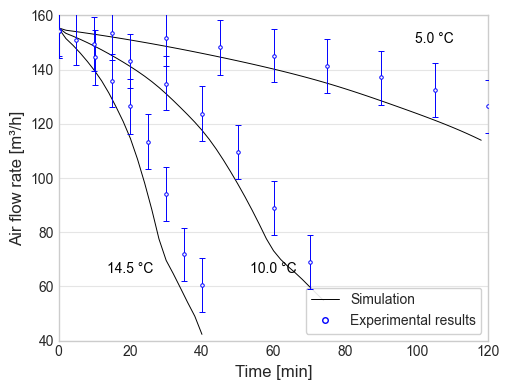

Plotted 25 error-bar points for p_delta


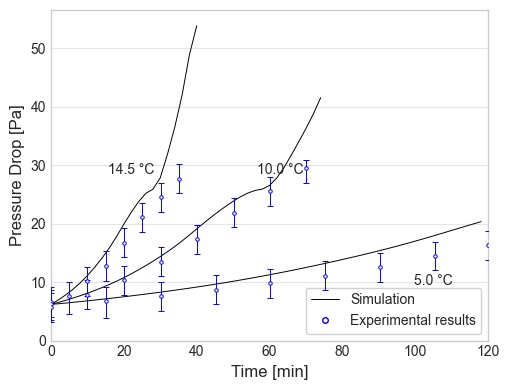

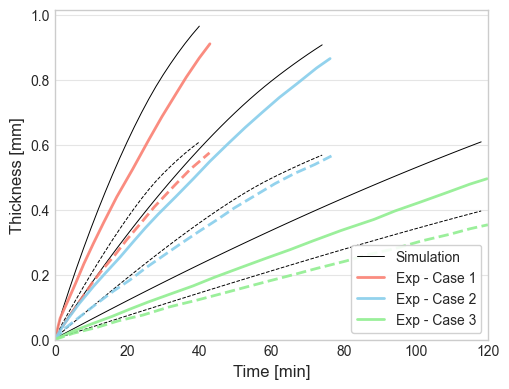

Plotted 34 error-bar points for mass_total


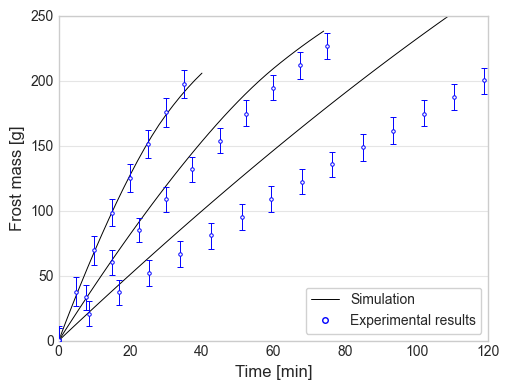

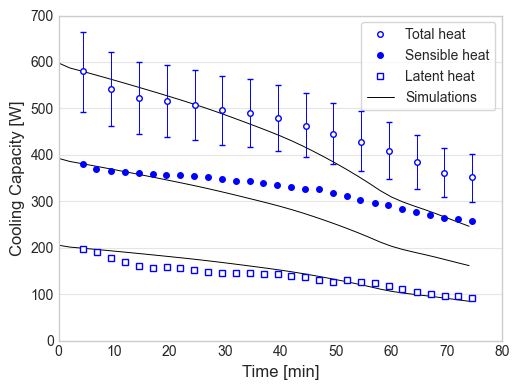

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

# Optional: Set a clean style
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except:
    plt.style.use('fast')

# ---------------------------------------------------------
# DATA LOCATIONS & MAPPING
# ---------------------------------------------------------
EXP_FOLDER_PATH = r"J:\Masterarbeit_Nils_Baumeister\da_Silva_Daten_extrahiert"

exp_file_map = {
    'vol_flow':  'air_flow_rate_all.csv',
    'p_delta':   'air_pressure_drop_all.csv',
    'mass':      'frost_mass_all.csv',
    'thickness': 'frost_thickness_simulation.csv'
}

# ---------------------------------------------------------
# CONFIGURATION
# ---------------------------------------------------------
# Format: (Col Name, Title, Y-Label, Multiplier, [Y-Min, Y-Max])
# Note: Use None for autoscaling. e.g., [0, None] starts at 0, auto max.
plot_specs = [
    (['vol_flow'], "Volume Flow Rate", "Air flow rate [m³/h]", 1.0, [40, 160], 'vol_flow'),
    (['p_delta'], "Airside Pressure Drop", "Pressure Drop [Pa]", 1.0, [0, None], 'p_delta'),
    # Note the explicit 'thickness' key at the end
    (['thickness_inlet', 'thickness_outlet'], "Frost Thickness", "Thickness [mm]", 1000.0, [0, None], 'thickness'),
    # Note the explicit 'mass' key at the end
    (['mass_total'], "Accumulated Frost Mass", "Frost mass [g]", 1000.0, [0, 250], 'mass'),
]

# ---------------------------------------------------------
# HELPER FUNCTIONS
# ---------------------------------------------------------
def load_and_clean_csv(filepath):
    """
    Loads CSV, forces numeric conversion, and DROPS headers/bad rows.
    """
    df = pd.read_csv(filepath, header=None)
    df.columns = ['time', 'value']
    
    df['time'] = pd.to_numeric(df['time'], errors='coerce')
    df['value'] = pd.to_numeric(df['value'], errors='coerce')
    
    df = df.dropna().reset_index(drop=True)
    return df

def get_time_separated_blocks(df):
    """Splits a dataframe into blocks based on time resets."""
    if len(df) == 0: return []
    
    df['diff'] = df['time'].diff()
    split_indices = df.index[df['diff'] < -0.5].tolist()
    boundaries = [0] + split_indices + [len(df)]
    
    blocks = []
    for i in range(len(boundaries) - 1):
        start = boundaries[i]
        end = boundaries[i+1]
        blocks.append(df.iloc[start:end].reset_index(drop=True))
    return blocks

def process_interleaved_triplets(df):
    """
    Handles data structured as: Row i (Upper), Row i+1 (Mean), Row i+2 (Lower)
    """
    n = len(df)
    remainder = n % 3
    if remainder != 0:
        print(f"Warning: Data length {n} not divisible by 3. Truncating last {remainder}.")
        df = df.iloc[:-remainder]
    
    upper = df.iloc[0::3].reset_index(drop=True)
    mean  = df.iloc[1::3].reset_index(drop=True)
    lower = df.iloc[2::3].reset_index(drop=True)
    
    x_avg = (upper['time'] + mean['time'] + lower['time']) / 3.0
    y_mean = mean['value']
    
    err_low = (y_mean - lower['value']).abs()
    err_high = (upper['value'] - y_mean).abs()
    
    return x_avg, y_mean, err_low, err_high

# ---------------------------------------------------------
# MAIN PLOTTING LOOP
# ---------------------------------------------------------
for col_names, title, y_label, multiplier, y_limits, exp_key in plot_specs:
    
    plt.figure(figsize=(5.2, 4), dpi=100) #300
    
    # 1. SIMULATION
    if 'results' in locals():
        for case_name, data in results.items():
            if case_name.startswith('Case 2'):
                case_name = "Simulation"
            else:
                case_name=None
            df = data['df']
            color = data['color']

            linestyles = ["-", "--"]
            labels = [case_name, None]
            for col_name, linestyle, label in zip(col_names, linestyles, labels):
                plt.plot(df.index, df[col_name] * multiplier, label=label, color="black", linewidth=0.7, linestyle=linestyle)
            
    # 2. EXPERIMENTAL
    if exp_key in exp_file_map:
        filename = exp_file_map[exp_key ]
        full_path = os.path.join(EXP_FOLDER_PATH, filename)
        
        if os.path.exists(full_path):
            try:
                ext_df = load_and_clean_csv(full_path)

                # --- CASE A: THICKNESS ---
                if exp_key == 'thickness':
                    blocks = get_time_separated_blocks(ext_df)
                    pair_colors = ['salmon', 'skyblue', 'lightgreen']
                    
                    for i, block in enumerate(blocks):
                        color_idx = i // 2
                        col = pair_colors[color_idx] if color_idx < len(pair_colors) else 'gray'
                        style = '-' if ((i+1)%2!=0) else '--'
                        
                        lbl = None
                        if i == 0: lbl = 'Exp - Case 1'
                        elif i == 2: lbl = 'Exp - Case 2'
                        elif i == 4: lbl = 'Exp - Case 3'
                        
                        plt.plot(block['time'], block['value'], color=col, linestyle=style, 
                                 linewidth=2.0, alpha=0.9, label=lbl)

                # --- CASE B: FLOW, PRESSURE, MASS ---
                else:
                    x, y, el, eh = process_interleaved_triplets(ext_df)
                    
                    plt.errorbar(
                        x, y, yerr=[el, eh],
                        fmt='o', color='blue', ecolor='blue',
                        markerfacecolor='white', markeredgewidth=0.7, markersize=2.5,
                        capsize=2, elinewidth=0.7, zorder=10
                    )

                    plt.plot(-100, 0, marker='o', color='blue',
                        markerfacecolor='white', markeredgewidth=1.0,
                        zorder=10, markersize=4, label="Experimental results", linestyle='None')
                    
                    print(f"Plotted {len(x)} error-bar points for {col_name}")

            except Exception as e:
                print(f"Error loading {filename}: {e}")
        else:
            print(f"File not found: {full_path}")

    if col_name == 'vol_flow':
        plt.text(20, 65, "14.5 °C", fontsize=10, ha='center', color='black')
        plt.text(60, 65, "10.0 °C", fontsize=10, ha='center', color='black')
        plt.text(105, 150, "5.0 °C", fontsize=10, ha='center', color='black')
    elif col_name == 'p_delta':
        plt.text(22, 28.5, "14.5 °C", fontsize=10, ha='center')
        plt.text(63, 28.5, "10.0 °C", fontsize=10, ha='center')
        plt.text(105, 9.5, "5.0 °C", fontsize=10, ha='center')
    elif col_name == 'mass':
        plt.text(18, 250, "14.5 °C", fontsize=10, ha='left')
        plt.text(60, 250, "10.0 °C", fontsize=10, ha='left')
        plt.text(100, 225, "5.0 °C", fontsize=10, ha='center')

    # Format
    plt.xlabel("Time [min]", fontsize=12)
    plt.ylabel(y_label, fontsize=12)
    plt.grid(False) 
    plt.gca().yaxis.grid(True, linestyle='-', alpha=0.5)
    plt.legend(loc='lower right', frameon=True, fancybox=True, framealpha=0.9)
    plt.xlim([0, 120])
    
    # APPLY Y-LIMITS FROM CONFIG
    if y_limits is not None:
        plt.ylim(y_limits)
        
    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------
# ADDITIONAL PLOT: Cooling Capacity
# ---------------------------------------------------------
plt.figure(figsize=(5.3, 4), dpi=100)



# 2. EXPERIMENTAL
exp_filename = "cooling_capacity_all.csv"
exp_path = os.path.join(EXP_FOLDER_PATH, exp_filename)

if os.path.exists(exp_path):
    try:
        ext_df = load_and_clean_csv(exp_path)
        blocks = get_time_separated_blocks(ext_df)
        
        # Block 0: Total
        if len(blocks) > 0:
            df_total = blocks[0]
            if len(df_total) > 0:
                x_t, y_t, el_t, eh_t = process_interleaved_triplets(df_total)
                plt.errorbar(
                    x_t, y_t, yerr=[el_t, eh_t],
                    fmt='o', color='blue', ecolor='blue',
                    markerfacecolor='white', markeredgewidth=1.0,
                    capsize=2, elinewidth=0.7, zorder=10, markersize=4
                )

                plt.plot(-100, 0, marker='o', color='blue',
                    markerfacecolor='white', markeredgewidth=1.0,
                    zorder=10, markersize=4, label="Total heat", linestyle='None')

        # Remaining Blocks
        cat_map = {0: ('Sensible heat', 'o', 'blue'), 1: ('Latent heat', 's', 'white')}
        for i, block in enumerate(blocks[1:]): 
            if i in cat_map:
                name, marker, mfc = cat_map[i]
                plt.plot(
                    block['time'], block['value'],
                    label=name,
                    color='blue', marker=marker, linestyle='None',
                    markerfacecolor=mfc, markeredgewidth=1.0, zorder=10,
                    markersize=4
                )
        # 1. SIMULATION
        if 'results' in locals():
            for case_name, data in results.items():
                if case_name.startswith('Case 2'): 
                    df = data['df']
                    col = data['color']
                    if 'Q_dot_total' in df.columns:
                        plt.plot(df.index, df['Q_dot_total'], color='black', label=f"Simulations", linewidth=0.7)
                        plt.plot(df.index, df['Q_dot_sens'], color='black', linewidth=0.7)#, label=f"{case_name} - Sensible")
                        plt.plot(df.index, df['Q_dot_total'] - df['Q_dot_sens'], color='black', linewidth=0.7)#, label=f"{case_name} - Latent")

    except Exception as e:
        print(f"Error loading {exp_filename}: {e}")

# Format
# plt.title("Cooling Capacity / Heat Transfer Rates", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Time [min]", fontsize=12)
plt.ylabel("Cooling Capacity [W]", fontsize=12)
plt.grid(False) 
plt.gca().yaxis.grid(True, linestyle='-', alpha=0.5)
plt.legend(loc='upper right', frameon=True)
plt.xlim([0,80])
plt.ylim([0, 700]) # Manually set for this specific plot
plt.tight_layout()
plt.show()